<a href="https://colab.research.google.com/github/minhyeok2001/CS492/blob/main/Diffusion-Assignment4-Distillation/sds_pds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
  !git clone https://github.com/minhyeok2001/CS492.git

Cloning into 'CS492'...
remote: Enumerating objects: 372, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 372 (delta 64), reused 91 (delta 27), pack-reused 231 (from 1)
Receiving objects: 100% (372/372), 201.99 MiB | 40.64 MiB/s, done.
Resolving deltas: 100% (94/94), done.
Updating files: 100% (253/253), done.


In [2]:
ls

CS492/  sample_data/


In [3]:
cd CS492

/content/CS492


In [4]:
ls

Diffusion-Assignment1-DDPM/             Diffusion-Assignment5-Synchronization/
Diffusion-Assignment2-DDIM-CFG/         Diffusion-Assignment6-DPMSolver/
Diffusion-Assignment3-ControlNet-LoRA/  Diffusion-Assignment7-Flow/
Diffusion-Assignment4-Distillation/     README.md


In [5]:
cd Diffusion-Assignment4-Distillation

/content/CS492/Diffusion-Assignment4-Distillation


In [6]:
ls

asset/  eval.py    LICENSE  outputs/      README.md         utils.py
data/   guidance/  main.py  __pycache__/  requirements.txt


In [7]:
!pip install torch==2.1.0 torchvision==0.16.0 torchaudio==2.1.0 --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
ERROR: Could not find a version that satisfies the requirement torch==2.1.0 (from versions: 2.2.0+cu121, 2.2.1+cu121, 2.2.2+cu121, 2.3.0+cu121, 2.3.1+cu121, 2.4.0+cu121, 2.4.1+cu121, 2.5.0+cu121, 2.5.1+cu121)
ERROR: No matching distribution found for torch==2.1.0


In [8]:
!pip install -r requirements.txt

  Cloning https://github.com/openai/CLIP.git (to revision dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1) to /tmp/pip-install-e358jv1l/clip_fc2ac798bc184d96a3bbab81ec486d01
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-install-e358jv1l/clip_fc2ac798bc184d96a3bbab81ec486d01
  Running command git rev-parse -q --verify 'sha^dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1'
  Running command git fetch -q https://github.com/openai/CLIP.git dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not 

In [53]:
from diffusers import DDIMScheduler, StableDiffusionPipeline

import torch
import torch.nn as nn

import random


class StableDiffusion(nn.Module):
    def __init__(self, args, t_range=[0.02, 0.98]):
        super().__init__()

        self.device = args.device
        self.dtype = args.precision
        print(f'[INFO] loading stable diffusion...')

        model_key = "stabilityai/stable-diffusion-2-1-base"
        pipe = StableDiffusionPipeline.from_pretrained(
            model_key, torch_dtype=self.dtype,
        )

        pipe.to(self.device)
        self.vae = pipe.vae
        self.tokenizer = pipe.tokenizer
        self.text_encoder = pipe.text_encoder
        self.unet = pipe.unet
        self.scheduler = DDIMScheduler.from_pretrained(
            model_key, subfolder="scheduler", torch_dtype=self.dtype,
        )

        del pipe

        self.num_train_timesteps = self.scheduler.config.num_train_timesteps
        self.t_range = t_range
        self.min_step = int(self.num_train_timesteps * t_range[0])
        self.max_step = int(self.num_train_timesteps * t_range[1])
        self.alphas = self.scheduler.alphas_cumprod.to(self.device) # for convenience

        print(f'[INFO] loaded stable diffusion!')

    @torch.no_grad()
    def get_text_embeds(self, prompt):
        inputs = self.tokenizer(prompt, padding='max_length', max_length=self.tokenizer.model_max_length, return_tensors='pt')
        embeddings = self.text_encoder(inputs.input_ids.to(self.device))[0]

        return embeddings


    def get_noise_preds(self, latents_noisy, t, text_embeddings, guidance_scale=100):
        latent_model_input = torch.cat([latents_noisy] * 2)

        tt = torch.cat([t] * 2)
        noise_pred = self.unet(latent_model_input, tt, encoder_hidden_states=text_embeddings).sample

        noise_pred_uncond, noise_pred_pos = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_pos - noise_pred_uncond)

        return noise_pred

    def get_sds_loss(
        self,
        latents,
        text_embeddings,
        guidance_scale=25,
        grad_scale=1,
    ):

        t = torch.randint(self.min_step,self.max_step,size=(1,)).to(torch.long).to(self.device)
        alpha_bar = self.alphas[t].view(1,1,1,1)
        gt_noise = torch.randn_like(latents)
        noisy_latents = torch.sqrt(alpha_bar) * latents + torch.sqrt(1-alpha_bar) * gt_noise

        with torch.no_grad():
          eps_hat = self.get_noise_preds(noisy_latents, t, text_embeddings, guidance_scale)

        ## 헐. 이렇게 안해주면 결국 U-NET 야코비안이 backward시에 자동생성되네? 빼주고싶어도?

        w = 1 - alpha_bar
        grad = w * (eps_hat - gt_noise)

        ## 아래에서 최종 loss 정리

        loss = (noisy_latents * grad).mean() * grad_scale

        #loss = torch.mean((eps_hat.detach() - gt_noise)**2)
        return loss



    def get_pds_loss(
        self, src_latents, tgt_latents,
        src_text_embedding, tgt_text_embedding,
        guidance_scale=7.5,
        grad_scale=1,
    ):

        B = src_latents.shape[0]

        t = torch.randint(self.min_step,self.max_step,size=(1,)).to(torch.long).to(self.device)

        gt_noise_t = torch.randn_like(src_latents)
        gt_noise_tm1 = torch.randn_like(src_latents)

        alpha_bar_t = self.alphas[t].view(B,1,1,1)
        alpha_bar_tm1 = self.alphas[torch.clamp(t-1,min=0)].view(B,1,1,1)


        def forward(x_0,alpha_bar,noise):
            return torch.sqrt(alpha_bar) * x_0 + torch.sqrt(1-alpha_bar) * noise

        src_x_t = forward(src_latents,alpha_bar_t,gt_noise_t)
        src_x_tm1 = forward(src_latents,alpha_bar_tm1,gt_noise_tm1)

        tgt_x_t = forward(tgt_latents,alpha_bar_t,gt_noise_t)
        tgt_x_tm1 = forward(tgt_latents,alpha_bar_tm1,gt_noise_tm1)

        alpha_t  = (alpha_bar_t / alpha_bar_tm1).clamp(min=1e-12, max=1-1e-12)
        beta_t   = (1.0 - alpha_t).clamp(min=1e-12)
        sigma2_t = ((1.0 - alpha_bar_tm1) / (1.0 - alpha_bar_t)) * beta_t
        sigma_t  = torch.sqrt(sigma2_t + 1e-20)

        ## 이제 x_t-1과 x_t의 관계를 이용해서 z 식 구하기
        with torch.no_grad():
          src_noise = self.get_noise_preds(src_x_t,t,src_text_embedding,guidance_scale)

        src_x0 = (src_x_t - torch.sqrt(1-alpha_bar_t)*src_noise)/torch.sqrt(alpha_bar_t)
        src_mu = ((torch.sqrt(alpha_bar_tm1) * beta_t / (1.0 - alpha_bar_t)) * src_x0 +(torch.sqrt(alpha_t)* (1.0 - alpha_bar_tm1) / (1.0 - alpha_bar_t)) * src_x_t)

        src_z = (src_x_tm1 - src_mu) / sigma_t

        with torch.no_grad():
            tgt_noise = self.get_noise_preds(tgt_x_t, t, tgt_text_embedding, guidance_scale)

        tgt_x0 = (tgt_x_t - torch.sqrt(1.0 - alpha_bar_t) * tgt_noise) / torch.sqrt(alpha_bar_t)

        tgt_mu = (
            (torch.sqrt(alpha_bar_tm1) * beta_t / (1.0 - alpha_bar_t)) * tgt_x0
            + (torch.sqrt(alpha_t)      * (1.0 - alpha_bar_tm1) / (1.0 - alpha_bar_t)) * tgt_x_t
        )

        tgt_z = (tgt_x_tm1 - tgt_mu) / sigma_t

        grad_xt = (tgt_z - src_z)
        loss = (tgt_x_t * grad_xt).sum(dim=(1,2,3)).mean() * grad_scale

        ## loss = (tgt_z - src_z).pow(2).mean() * grad_scale

        return loss


    @torch.no_grad()
    def decode_latents(self, latents):

        latents = 1 / self.vae.config.scaling_factor * latents

        imgs = self.vae.decode(latents).sample
        imgs = (imgs / 2 + 0.5).clamp(0, 1)

        return imgs

    @torch.no_grad()
    def encode_imgs(self, imgs):
        # imgs: [B, 3, H, W]

        imgs = 2 * imgs - 1

        posterior = self.vae.encode(imgs).latent_dist
        latents = posterior.sample() * self.vae.config.scaling_factor

        return latents


가짜 LOSS 함수 !! ( 즉 jacobian 제거를 위한 .. )
-> 이렇게 해줘도 되긴 한데, 그냥 detach랑 no_grad 사용해도 OK


$$
\nabla_{x_0} \tilde L = \sqrt{\bar\alpha_t}\,w(t)\,(\hat\epsilon - \epsilon)
$$

In [54]:
import os
import json
from PIL import Image
import numpy as np
from tqdm import tqdm
import math
import argparse
from types import SimpleNamespace
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR

from utils import *


def seed_everything(seed=2024):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, num_cycles: float = 0.5):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * float(num_cycles) * 2.0 * progress)))

    return LambdaLR(optimizer, lr_lambda, -1)


def init_model(args):
    model = StableDiffusion(args, t_range=[0.02, 0.98])
    return model


def run(args):
    args.precision = torch.float16 if args.precision == "fp16" else torch.float32

    # Initialize model and optimizing parameters
    model = init_model(args)
    device = model.device
    guidance_scale = args.guidance_scale
    steps = args.step

    # Get text embeddings
    cond_embeddings = model.get_text_embeds(args.prompt)
    uncond_embeddings = model.get_text_embeds(args.negative_prompt)
    text_embeddings = torch.cat([uncond_embeddings, cond_embeddings])

    if args.loss_type in ["pds"]:
        src_img = Image.open(args.src_img_path).convert("RGB")
        src_img.save(os.path.join(args.save_dir, "src_img.png"))

        torch_src_img = pil_to_torch(src_img).to(device)
        src_h, src_w = torch_src_img.shape[-2], torch_src_img.shape[-1]

        # resize such that the shortest side is 512
        l = min(src_h, src_w)
        new_h, new_w = int(512 / l * src_h), int(512 / l * src_w)
        src_img_tensor = F.interpolate(torch_src_img, (new_h, new_w), mode="bilinear")
        print("Source image shape:", src_img_tensor.shape)
        src_latents = model.encode_imgs(src_img_tensor)

        tgt_embeddings = model.get_text_embeds(args.edit_prompt)
        edit_embeddings = torch.cat([uncond_embeddings, tgt_embeddings])

        # Initialize latents with source images
        latents = src_latents.clone().detach().requires_grad_(True)

    else:
        # Initialize latents with random Gaussian for generation
        latents = nn.Parameter(
            torch.randn(
                1, 4, 64, 64,
                device=device,
                dtype=args.precision,
            )
        )

    optimizer = torch.optim.AdamW([latents], lr=1e-1, weight_decay=0)
    scheduler = get_cosine_schedule_with_warmup(optimizer, 100, int(steps*1.5))

    # Run optimization
    for step in tqdm(range(steps)):
        optimizer.zero_grad()

        if args.loss_type == "sds":
            loss = model.get_sds_loss(
                latents=latents,
                text_embeddings=text_embeddings,
                guidance_scale=guidance_scale,
            )

        elif args.loss_type == "pds":
            loss = model.get_pds_loss(
                src_latents=src_latents, tgt_latents=latents,
                src_text_embedding=text_embeddings, tgt_text_embedding=edit_embeddings,
                guidance_scale=guidance_scale,
            )

        else:
            raise ValueError("Invalid loss type")


        (2000*loss).backward()
        optimizer.step()
        scheduler.step()

        if step%args.log_step == 0:
            with torch.no_grad():
                img = model.decode_latents(latents)
                img_save_path = os.path.join(args.save_dir, f"{step}.png")
                torch_to_pil(img).save(img_save_path)
                print("Step: {}, Loss: {}".format(step, loss.item()))

    img = model.decode_latents(latents)
    if args.loss_type == "sds":
        prompt_key = args.prompt.replace(" ", "_")
    else:
        prompt_key = args.edit_prompt.replace(" ", "_")
    img_save_path = os.path.join(args.save_dir, f"{prompt_key}.png")
    torch_to_pil(img).save(img_save_path)
    print(f"Save path: {img_save_path}")


def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--prompt", type=str)
    parser.add_argument("--negative_prompt", type=str, default="low quality")
    parser.add_argument("--edit_prompt", type=str, default=None)
    parser.add_argument("--src_img_path", type=str, default=None)
    parser.add_argument("--save_dir", type=str, default="./outputs")

    parser.add_argument("--loss_type", type=str, default="sds")
    parser.add_argument("--guidance_scale", type=float, default=7.5)
    parser.add_argument("--step", type=int, default=500)

    parser.add_argument("--device", type=int, default=0)
    parser.add_argument("--lr", type=float, default=1e-3)

    parser.add_argument("--log_step", type=int, default=25)
    parser.add_argument("--precision", type=str, default="fp32")

    return parser.parse_args()

In [55]:

## SDS

def main():

    args = SimpleNamespace(
        prompt="a dog in the park",
        negative_prompt="low quality",
        edit_prompt=None,
        src_img_path=None,
        save_dir="./outputs",
        loss_type="sds",
        guidance_scale=25,
        step=500,
        device=0,
        lr=1e-3,
        log_step=25,
        precision="fp32"
    )
    assert args.loss_type in ["sds", "pds"], "Invalid loss type"
    if args.loss_type in ["pds"]:
        assert args.edit_prompt is not None, f"edit_prompt is required for {args.loss_type}"
        assert args.src_img_path is not None, f"src_img_path is required for {args.loss_type}"

    if os.path.exists(args.save_dir):
        print("[*] Save directory already exists. Overwriting...")
    else:
        os.makedirs(args.save_dir)

    log_opt = vars(args)
    config_path = os.path.join(args.save_dir, "run_config.yaml")
    with open(config_path, "w") as f:
        json.dump(log_opt, f, indent=4)

    print(f"[*] Running {args.loss_type}")
    run(args)



if __name__ == "__main__":
    main()


[*] Save directory already exists. Overwriting...
[*] Running sds
[INFO] loading stable diffusion...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

[INFO] loaded stable diffusion!


  1%|          | 3/500 [00:00<00:45, 10.89it/s]

Step: 0, Loss: 0.047600969672203064


...

Step: 450, Loss: -0.029600389301776886


 96%|█████████▌| 479/500 [00:36<00:01, 11.35it/s]

Step: 475, Loss: -0.012145878747105598


100%|██████████| 500/500 [00:37<00:00, 13.33it/s]


Save path: ./outputs/a_dog_in_the_park.png


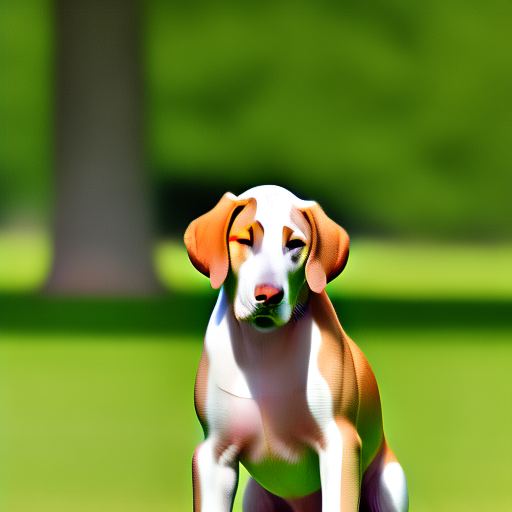

In [56]:
from IPython.display import Image, display

display(Image(filename="./outputs/a_dog_in_the_park.png"))

In [45]:

#from IPython.display import Image, display
from PIL import Image

def main():

    args = SimpleNamespace(
        prompt="a boat in a river",
        negative_prompt="low quality",
        edit_prompt="a golden boat in a river",
        src_img_path="/content/CS492/Diffusion-Assignment4-Distillation/data/imgs/a_boat_in_a_river.png",
        save_dir="./outputs",
        loss_type="pds",          # sds / pds
        guidance_scale=7.5,
        step=500,
        device=0,                 # GPU index
        lr=1e-3,
        log_step=25,
        precision="fp32"          # "fp32" or "fp16"
    )
    assert args.loss_type in ["sds", "pds"], "Invalid loss type"
    if args.loss_type in ["pds"]:
        assert args.edit_prompt is not None, f"edit_prompt is required for {args.loss_type}"
        assert args.src_img_path is not None, f"src_img_path is required for {args.loss_type}"

    if os.path.exists(args.save_dir):
        print("[*] Save directory already exists. Overwriting...")
    else:
        os.makedirs(args.save_dir)

    log_opt = vars(args)
    config_path = os.path.join(args.save_dir, "run_config.yaml")
    with open(config_path, "w") as f:
        json.dump(log_opt, f, indent=4)

    print(f"[*] Running {args.loss_type}")
    run(args)



if __name__ == "__main__":
    main()

[*] Save directory already exists. Overwriting...
[*] Running pds
[INFO] loading stable diffusion...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

[INFO] loaded stable diffusion!
Source image shape: torch.Size([1, 3, 512, 512])


  0%|          | 1/500 [00:00<02:23,  3.49it/s]

Step: 0, Loss: -0.7216364145278931


...

Step: 450, Loss: 9.10758113861084


 95%|█████████▌| 476/500 [01:07<00:04,  5.19it/s]

Step: 475, Loss: 11.667779922485352


100%|██████████| 500/500 [01:10<00:00,  7.08it/s]


Save path: ./outputs/a_golden_boat_in_a_river.png


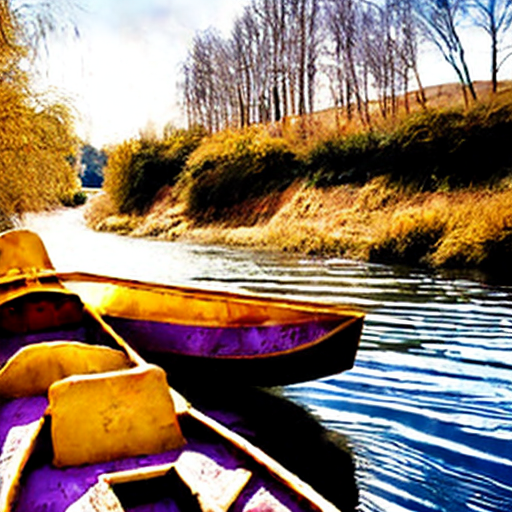

In [46]:
from IPython.display import Image, display

display(Image(filename="./outputs/a_golden_boat_in_a_river.png"))